In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from umap import UMAP

from training import embed_texts, load_checkpoint_bundle

DATA_DIR = Path('data/ToolVerifier')
DATASET_PATH = DATA_DIR / 'tool_embedding_dataset.jsonl'
EMBED_ARCHITECTURE = 'normal'
EMBED_LOSS = 'circle'
CHECKPOINT_PATH = DATA_DIR / 'output' / EMBED_ARCHITECTURE / EMBED_LOSS / 'best.pt'
# BENCHMARK_PATH = DATA_DIR / 'benchmark.json'
DEVICE = 'cuda:3' if torch.cuda.is_available() else 'cpu'
MAX_SAMPLES = 2000
TOP_K_TOOLS = 100
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f'device: {DEVICE}')
print(f'dataset: {DATASET_PATH}')
print(f'checkpoint: {CHECKPOINT_PATH}')


/scratch4/home/akrik/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda:3
dataset: data/ToolVerifier/tool_embedding_dataset.jsonl
checkpoint: data/ToolVerifier/output/normal/circle/best.pt


In [2]:
def load_jsonl(path):
    with path.open('r', encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]


rows = load_jsonl(DATASET_PATH)
random.shuffle(rows)
rows = rows[:MAX_SAMPLES]

bundle = load_checkpoint_bundle(CHECKPOINT_PATH, device=DEVICE)
tool_names = bundle['tool_names']
tool_to_idx = {tool: idx for idx, tool in enumerate(tool_names)}
texts = [row.get('query', row.get('text', '')) for row in rows]
labels = np.array([tool_to_idx[row['tool']] for row in rows])
tool_counts = Counter(row['tool'] for row in rows)

embeddings = embed_texts(
    model=bundle['model'],
    tokenizer=bundle['tokenizer'],
    texts=texts,
    device=DEVICE,
    max_length=bundle['max_length'],
    batch_size=32,
).numpy()
centroids = bundle['centroids'].detach().cpu().numpy()

print(f'samples: {len(rows)}')
print(f'unique tools in sample: {len(tool_counts)}')
print(f'embedding shape: {embeddings.shape}')
print(tool_counts.most_common(10))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1734.49it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                    

samples: 2000
unique tools in sample: 124
embedding shape: (2000, 128)
[('get_stock_price', 48), ('get_bank_name', 46), ('airline_seat_selector', 46), ('get_birthday_date', 45), ('real_estate_finder', 36), ('translate_text', 36), ('get_sunset_time', 36), ('movie_recommendation', 36), ('order_pizza', 35), ('restaurant_recommender', 35)]


In [3]:
def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.clip(norms, 1e-12, None)
    return matrix / norms


normalized_embeddings = normalize_matrix(embeddings)
normalized_centroids = normalize_matrix(centroids)
scores = normalized_embeddings @ normalized_centroids.T
predictions = scores.argmax(axis=1)
retrieval_accuracy = float((predictions == labels).mean())

print(f'retrieval accuracy on sample rows: {retrieval_accuracy:.4f}')
if len(np.unique(labels)) > 1:
    sil = silhouette_score(embeddings, labels, metric='cosine')
    print(f'silhouette score: {sil:.4f}')
else:
    print('Need at least two tools for silhouette score.')


retrieval accuracy on sample rows: 0.9485
silhouette score: 0.5745


In [4]:
OVERLAP_MARGIN = 0.05
MIN_TOOL_SAMPLES = 5
TOP_OVERLAP_ROWS = 15
HEATMAP_TOOLS = 20


def compute_overlap_tables(
    rows,
    scores,
    labels,
    predictions,
    tool_names,
    normalized_centroids,
    overlap_margin=0.05,
    min_tool_samples=5,
):
    true_scores = scores[np.arange(len(labels)), labels]
    competing_scores = scores.copy()
    competing_scores[np.arange(len(labels)), labels] = -np.inf
    closest_rival_idx = competing_scores.argmax(axis=1)
    closest_rival_scores = competing_scores[np.arange(len(labels)), closest_rival_idx]
    margins = true_scores - closest_rival_scores

    sample_df = pd.DataFrame(
        {
            'query': [row.get('query', row.get('text', '')) for row in rows],
            'tool': [row['tool'] for row in rows],
            'predicted_tool': [tool_names[idx] for idx in predictions],
            'closest_rival_tool': [tool_names[idx] for idx in closest_rival_idx],
            'true_score': true_scores,
            'closest_rival_score': closest_rival_scores,
            'margin': margins,
            'misclassified': predictions != labels,
            'near_overlap': margins <= overlap_margin,
        }
    )

    overlap_matrix = np.full((len(tool_names), len(tool_names)), np.nan, dtype=float)
    confusion_matrix = np.full((len(tool_names), len(tool_names)), np.nan, dtype=float)
    tool_rows = []
    label_counts = np.bincount(labels, minlength=len(tool_names))

    for idx, tool in enumerate(tool_names):
        mask = labels == idx
        count = int(mask.sum())
        if count == 0:
            continue

        tool_scores = scores[mask]
        self_scores = tool_scores[:, idx]
        overlap_matrix[idx, :] = (tool_scores >= (self_scores[:, None] - overlap_margin)).mean(axis=0)
        overlap_matrix[idx, idx] = np.nan

        pred_counts = np.bincount(predictions[mask], minlength=len(tool_names))
        confusion_matrix[idx, :] = pred_counts / count
        confusion_matrix[idx, idx] = np.nan

        tool_samples = sample_df.loc[mask]
        rival_counts = tool_samples['closest_rival_tool'].value_counts()

        tool_rows.append(
            {
                'tool': tool,
                'count': count,
                'accuracy': 1.0 - float(tool_samples['misclassified'].mean()),
                'near_overlap_rate': float(tool_samples['near_overlap'].mean()),
                'mean_margin': float(tool_samples['margin'].mean()),
                'p10_margin': float(tool_samples['margin'].quantile(0.10)),
                'mean_true_score': float(tool_samples['true_score'].mean()),
                'mean_rival_score': float(tool_samples['closest_rival_score'].mean()),
                'most_common_rival': rival_counts.index[0],
                'most_common_rival_share': float(rival_counts.iloc[0] / count),
            }
        )

    pair_rows = []
    for i, tool_a in enumerate(tool_names):
        for j in range(i + 1, len(tool_names)):
            tool_b = tool_names[j]
            if label_counts[i] < min_tool_samples or label_counts[j] < min_tool_samples:
                continue
            pair_rows.append(
                {
                    'tool_a': tool_a,
                    'tool_b': tool_b,
                    'samples_a': int(label_counts[i]),
                    'samples_b': int(label_counts[j]),
                    'a_to_b_overlap': float(overlap_matrix[i, j]),
                    'b_to_a_overlap': float(overlap_matrix[j, i]),
                    'mutual_overlap': float(np.nanmean([overlap_matrix[i, j], overlap_matrix[j, i]])),
                    'a_to_b_confusion': float(confusion_matrix[i, j]),
                    'b_to_a_confusion': float(confusion_matrix[j, i]),
                    'centroid_cosine': float(normalized_centroids[i] @ normalized_centroids[j]),
                }
            )

    tool_df = pd.DataFrame(tool_rows).sort_values(
        ['near_overlap_rate', 'mean_margin'],
        ascending=[False, True],
    )
    pair_df = pd.DataFrame(pair_rows).sort_values(
        ['mutual_overlap', 'centroid_cosine'],
        ascending=[False, False],
    )
    return sample_df, tool_df, pair_df, overlap_matrix, confusion_matrix


def show_overlap_examples(tool_a, tool_b, n=10):
    mask = (
        ((sample_overlap_df['tool'] == tool_a) & (sample_overlap_df['closest_rival_tool'] == tool_b))
        | ((sample_overlap_df['tool'] == tool_b) & (sample_overlap_df['closest_rival_tool'] == tool_a))
    )
    columns = [
        'tool',
        'predicted_tool',
        'closest_rival_tool',
        'true_score',
        'closest_rival_score',
        'margin',
        'query',
    ]
    return (
        sample_overlap_df.loc[mask, columns]
        .sort_values(['margin', 'true_score'], ascending=[True, False])
        .head(n)
    )


sample_overlap_df, tool_overlap_df, pair_overlap_df, overlap_matrix, confusion_matrix = compute_overlap_tables(
    rows=rows,
    scores=scores,
    labels=labels,
    predictions=predictions,
    tool_names=tool_names,
    normalized_centroids=normalized_centroids,
    overlap_margin=OVERLAP_MARGIN,
    min_tool_samples=MIN_TOOL_SAMPLES,
)

print(
    f"global near-overlap rate (margin <= {OVERLAP_MARGIN:.2f}): "
    f"{sample_overlap_df['near_overlap'].mean():.4f}"
)
print('tools with the smallest margins / highest overlap risk')
display(tool_overlap_df.head(TOP_OVERLAP_ROWS).round(4))

print('most-overlapping tool pairs')
display(pair_overlap_df.head(TOP_OVERLAP_ROWS).round(4))


global near-overlap rate (margin <= 0.05): 0.1005
tools with the smallest margins / highest overlap risk


,tool,count,accuracy,near_overlap_rate,mean_margin,p10_margin,mean_true_score,mean_rival_score,most_common_rival,most_common_rival_share
96,search_jobs,10,0.4000,1.0000,-0.0275,-0.1212,0.8633,0.8908,job_search,0.6000
13,calculator,12,0.7500,0.7500,0.0259,-0.0233,0.8989,0.8730,calculator_tool,0.5833
119,travel_distance_compute,11,0.8182,0.6364,0.0449,-0.0142,0.9180,0.8731,travel_distance,0.9091
81,movie_review,12,0.6667,0.5833,0.0463,-0.0858,0.9134,0.8671,get_movie_reviews,0.8333
14,calculator_basic,11,0.8182,0.5455,0.0320,-0.0883,0.8706,0.8386,calculator,0.6364
16,calculator_tool,12,0.6667,0.5000,0.0501,-0.0183,0.9008,0.8507,calculator,1.0000
118,travel_distance,35,0.8286,0.4286,0.0294,-0.0104,0.9265,0.8971,travel_distance_compute,0.9429
109,traffic_report_generator,12,0.7500,0.4167,0.0614,-0.0696,0.8648,0.8034,traffic_report,1.0000
30,find_restaurants,23,0.8261,0.3913,0.0809,-0.0261,0.8148,0.7338,restaurant_finder,0.6957
24,convert_currency,11,0.8182,0.3636,0.0723,-0.0057,0.8640,0.7916,currency_converter,1.0000


most-overlapping tool pairs


,tool_a,tool_b,samples_a,samples_b,a_to_b_overlap,b_to_a_overlap,mutual_overlap,a_to_b_confusion,b_to_a_confusion,centroid_cosine
1523,calculator,calculator_tool,12,12,0.5833,0.5000,0.5417,0.1667,0.3333,0.9225
7611,travel_distance,travel_distance_compute,35,11,0.4286,0.5455,0.4870,0.1143,0.1818,0.9406
6422,job_search,search_jobs,12,10,0.2500,0.6000,0.4250,0.0000,0.3000,0.9253
5305,get_movie_reviews,movie_review,11,12,0.1818,0.5833,0.3826,0.0000,0.3333,0.9134
7491,traffic_report,traffic_report_generator,24,12,0.3333,0.4167,0.3750,0.2917,0.2500,0.8889
2677,convert_currency,currency_converter,11,35,0.3636,0.2571,0.3104,0.1818,0.0857,0.9027
1521,calculator,calculator_basic,12,11,0.2500,0.3636,0.3068,0.0833,0.0909,0.9192
1631,calculator_basic,calculator_expression,11,11,0.2727,0.2727,0.2727,0.0000,0.0000,0.8065
7455,taxi_cost_estimator,taxi_estimator,12,24,0.2500,0.2917,0.2708,0.0833,0.1667,0.8751
273,book_flight,flight_booking,12,12,0.0833,0.3333,0.2083,0.0000,0.2500,0.8461


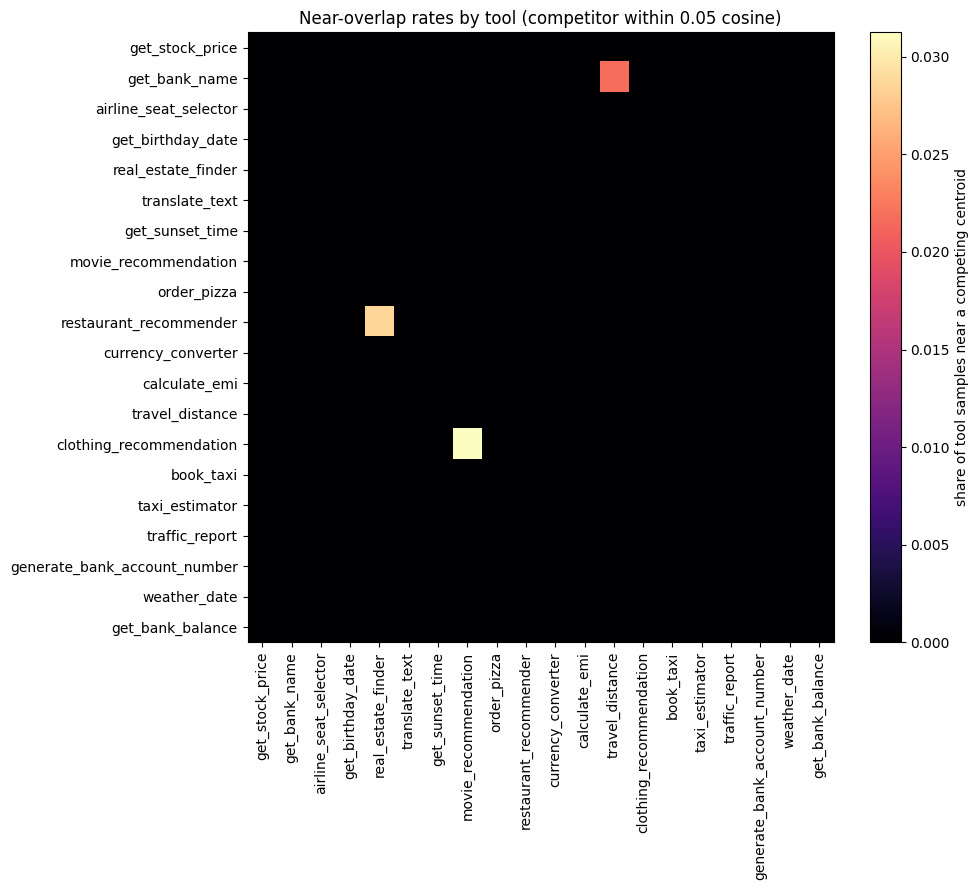

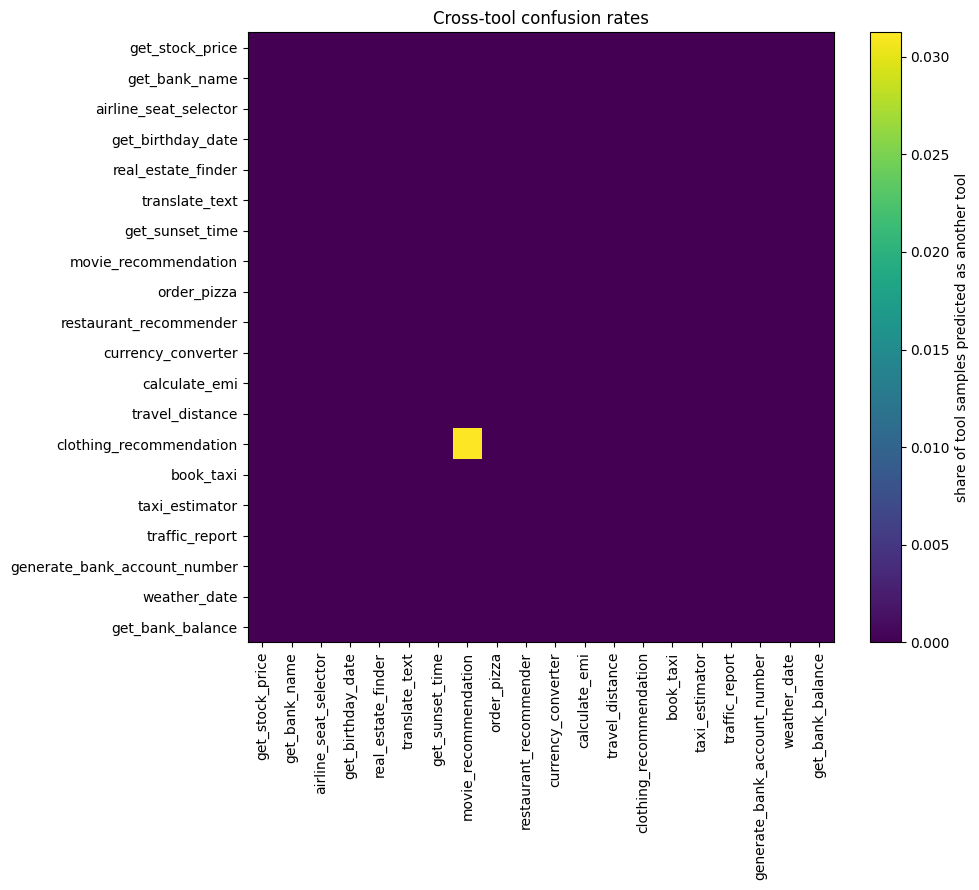

Top overlap pair: calculator vs calculator_tool (mutual overlap=0.5417, centroid cosine=0.9225)


,tool,predicted_tool,closest_rival_tool,true_score,closest_rival_score,margin,query
74,calculator_tool,calculator,calculator,0.8044,0.9096,-0.1052,What's 7 times 9?
410,calculator,calculator_tool,calculator_tool,0.8213,0.8705,-0.0492,Take away 12 from 30.
964,calculator_tool,calculator,calculator,0.9181,0.9374,-0.0193,Divide 100 by 4.
149,calculator_tool,calculator,calculator,0.9336,0.9429,-0.0093,Multiply 6 by 8.
1867,calculator,calculator_tool,calculator_tool,0.9233,0.9260,-0.0027,I need to subtract 8 from 50.
828,calculator_tool,calculator,calculator,0.8831,0.8833,-0.0002,Add 15 and 27 together.
1936,calculator_tool,calculator_tool,calculator,0.8853,0.8763,0.0090,How much is 12 plus 18?
1568,calculator_tool,calculator_tool,calculator,0.9463,0.9182,0.0281,I need to subtract 9 from 25.
190,calculator,calculator,calculator_tool,0.9324,0.9031,0.0294,Multiply 6 by 9 for me.
463,calculator,calculator,calculator_tool,0.9467,0.9167,0.0300,Subtract 5 from 100.


In [5]:
def plot_overlap_heatmap(matrix, tools, title, colorbar_label, cmap='magma'):
    plot_values = np.nan_to_num(matrix, nan=0.0)
    vmax = plot_values.max()
    if vmax <= 0:
        vmax = 1.0

    plt.figure(figsize=(max(10, 0.45 * len(tools)), max(8, 0.45 * len(tools))))
    image = plt.imshow(plot_values, cmap=cmap, vmin=0.0, vmax=vmax, aspect='auto')
    plt.colorbar(image, label=colorbar_label)
    plt.xticks(range(len(tools)), tools, rotation=90)
    plt.yticks(range(len(tools)), tools)
    plt.title(title)
    plt.tight_layout()
    plt.show()


heatmap_tools = [tool for tool, _ in tool_counts.most_common(HEATMAP_TOOLS)]
heatmap_idx = [tool_to_idx[tool] for tool in heatmap_tools]

plot_overlap_heatmap(
    overlap_matrix[np.ix_(heatmap_idx, heatmap_idx)],
    heatmap_tools,
    f'Near-overlap rates by tool (competitor within {OVERLAP_MARGIN:.2f} cosine)',
    'share of tool samples near a competing centroid',
)

plot_overlap_heatmap(
    confusion_matrix[np.ix_(heatmap_idx, heatmap_idx)],
    heatmap_tools,
    'Cross-tool confusion rates',
    'share of tool samples predicted as another tool',
    cmap='viridis',
)

if not pair_overlap_df.empty:
    top_pair = pair_overlap_df.iloc[0]
    print(
        f"Top overlap pair: {top_pair['tool_a']} vs {top_pair['tool_b']} "
        f"(mutual overlap={top_pair['mutual_overlap']:.4f}, "
        f"centroid cosine={top_pair['centroid_cosine']:.4f})"
    )
    display(show_overlap_examples(top_pair['tool_a'], top_pair['tool_b'], n=10).round(4))


/scratch4/home/akrik/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/scratch4/home/akrik/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_2317691/2155022479.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


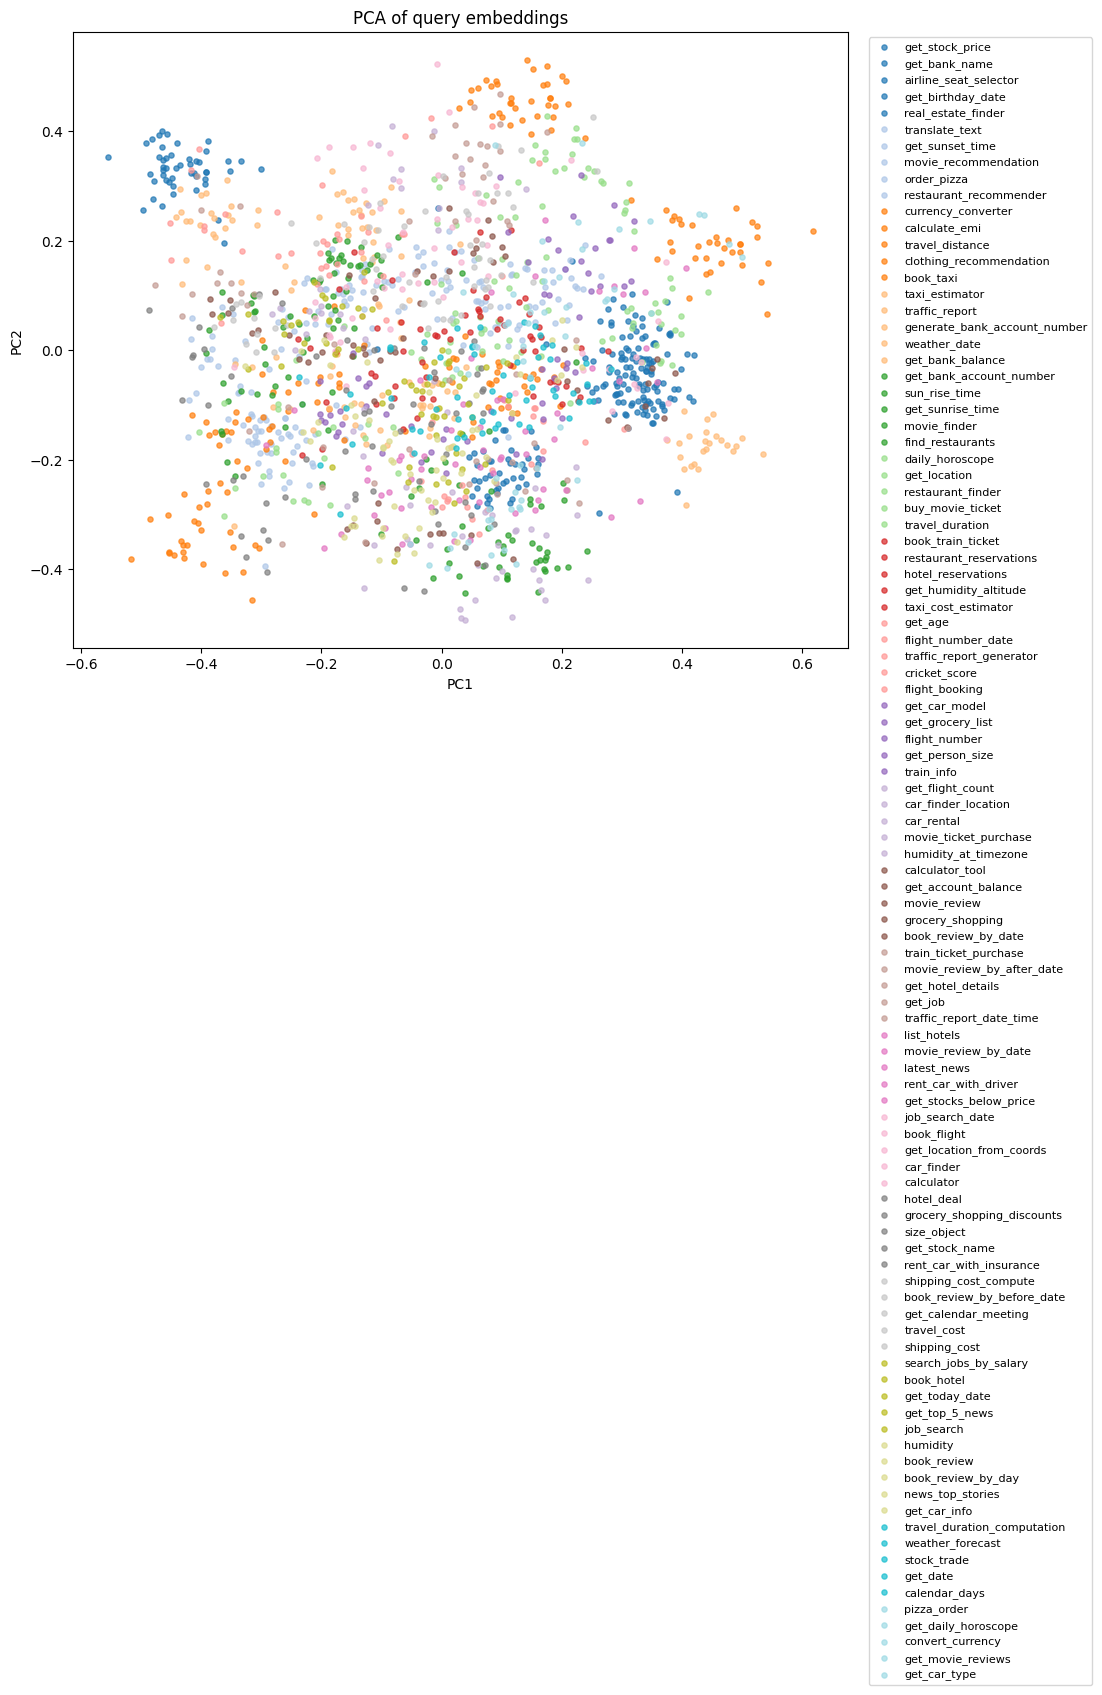

/tmp/ipykernel_2317691/2155022479.py:22: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



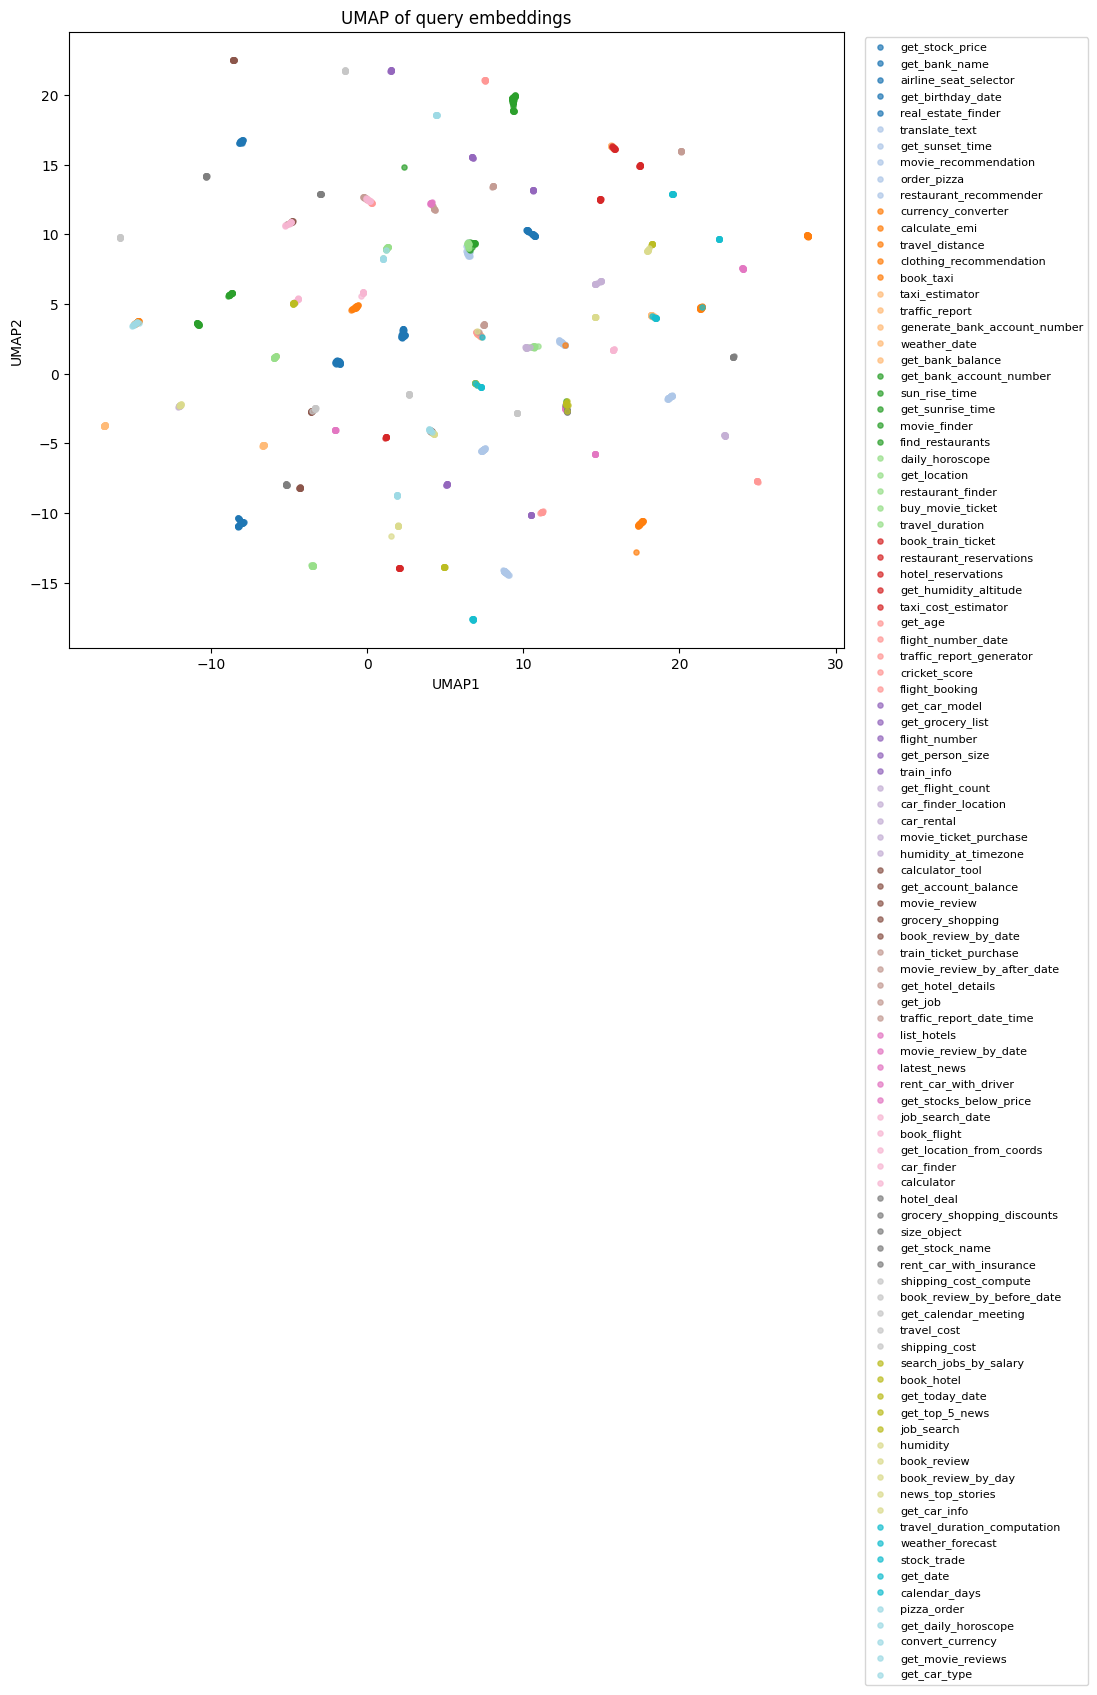

In [6]:
top_tools = [tool for tool, _ in tool_counts.most_common(TOP_K_TOOLS)]
row_tools = np.array([row['tool'] for row in rows])
sample_queries = np.array(texts)
tool_point_idx = {tool: np.flatnonzero(row_tools == tool) for tool in top_tools}
tool_colors = plt.cm.tab20(np.linspace(0, 1, len(top_tools)))


def to_plotly_rgba(color, alpha=0.7):
    red, green, blue = np.round(np.array(color[:3]) * 255).astype(int)
    return f'rgba({red}, {green}, {blue}, {alpha})'


def plot_projection_2d(xy, title, x_label='dim 1', y_label='dim 2'):
    fig, ax = plt.subplots(figsize=(10, 8))
    for color, tool in zip(tool_colors, top_tools):
        idx = tool_point_idx[tool]
        ax.scatter(xy[idx, 0], xy[idx, 1], s=14, alpha=0.7, color=color, label=tool)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_projection_3d(xyz, title, labels=('dim 1', 'dim 2', 'dim 3')):
    try:
        import plotly.graph_objects as go
    except ImportError as exc:
        raise ImportError(
            'Install plotly to use the interactive 3D projections: pip install plotly'
        ) from exc

    traces = []
    for color, tool in zip(tool_colors, top_tools):
        idx = tool_point_idx[tool]
        traces.append(
            go.Scatter3d(
                x=xyz[idx, 0],
                y=xyz[idx, 1],
                z=xyz[idx, 2],
                mode='markers',
                name=tool,
                showlegend=False,
                marker=dict(
                    size=4,
                    opacity=0.65,
                    color=to_plotly_rgba(color),
                ),
                customdata=np.column_stack([sample_queries[idx], row_tools[idx]]),
                hovertemplate=(
                    '<b>Sample</b>: %{customdata[0]}<br>'
                    '<b>Tool</b>: %{customdata[1]}<br>'
                    f'{labels[0]}: %{{x:.2f}}<br>'
                    f'{labels[1]}: %{{y:.2f}}<br>'
                    f'{labels[2]}: %{{z:.2f}}'
                    '<extra></extra>'
                ),
            )
        )

    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        showlegend=False,
        height=750,
        margin=dict(l=0, r=0, b=0, t=50),
        scene=dict(
            xaxis_title=labels[0],
            yaxis_title=labels[1],
            zaxis_title=labels[2],
            aspectmode='data',
        ),
    )
    fig.show()


pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(embeddings)
pca_3d = PCA(n_components=3, random_state=SEED).fit_transform(embeddings)
umap_2d = UMAP(n_components=2, random_state=SEED).fit_transform(embeddings)
umap_3d = UMAP(n_components=3, random_state=SEED).fit_transform(embeddings)

plot_projection_2d(pca_2d, 'PCA of query embeddings', x_label='PC1', y_label='PC2')
plot_projection_3d(pca_3d, '3D PCA of query embeddings', labels=('PC1', 'PC2', 'PC3'))

plot_projection_2d(umap_2d, 'UMAP of query embeddings', x_label='UMAP1', y_label='UMAP2')
plot_projection_3d(umap_3d, '3D UMAP of query embeddings', labels=('UMAP1', 'UMAP2', 'UMAP3'))


In [7]:
examples = []
for idx in random.sample(range(len(rows)), min(12, len(rows))):
    top3_idx = scores[idx].argsort()[::-1][:3]
    examples.append(
        {
            'query': rows[idx]['query'],
            'expected_tool': rows[idx]['tool'],
            'predicted_tool': tool_names[int(predictions[idx])],
            'top3_tools': ', '.join(tool_names[i] for i in top3_idx),
        }
    )

pd.DataFrame(examples)


,query,expected_tool,predicted_tool,top3_tools
0,I need a minivan in Denver for my family trip ...,rent_car_with_insurance,rent_car_with_insurance,"rent_car_with_insurance, car_rental, traffic_r..."
1,What's the info for meeting 5000?,get_calendar_meeting,get_calendar_meeting,"get_calendar_meeting, job_numbers, calendar_date"
2,"I need the monthly payment for a 45,000 euro c...",emi_calculator,emi_calculator,"emi_calculator, calculate_emi, get_news"
3,What's the traffic like in Chicago right now?,traffic_report,traffic_report,"traffic_report, traffic_report_generator, traf..."
4,Which financial institution does Daniel Garcia...,get_bank_name,get_bank_name,"get_bank_name, get_stock_name, shipping_cost_c..."
5,"What does row 10, column C look like?",airline_seat_selector,airline_seat_selector,"airline_seat_selector, get_hotel_details, gene..."
6,Can you find me a double room at the Hilton in...,hotel_reservations,hotel_reservations,"hotel_reservations, list_hotels, book_hotel_room"
7,I need the bank name associated with SWIFT cod...,get_bank_name,get_bank_name,"get_bank_name, get_stock_name, clothing_recomm..."
8,How long would a trip from Austin to Dallas take?,travel_duration,travel_duration,"travel_duration, travel_distance_compute, trav..."
9,I need to know the balance of my checking acco...,get_account_balance,get_account_balance,"get_account_balance, job_search_date, traffic_..."


In [8]:
# with BENCHMARK_PATH.open('r', encoding='utf-8') as handle:
#     benchmark = json.load(handle)['scenarios']

# benchmark_texts = [item['input'] for item in benchmark]
# benchmark_embeddings = embed_texts(
#     model=bundle['model'],
#     tokenizer=bundle['tokenizer'],
#     texts=benchmark_texts,
#     device=DEVICE,
#     max_length=bundle['max_length'],
#     batch_size=32,
# ).numpy()
# benchmark_scores = normalize_matrix(benchmark_embeddings) @ normalized_centroids.T

# report = []
# for scenario, row_scores in zip(benchmark, benchmark_scores):
#     top5_idx = row_scores.argsort()[::-1][:5]
#     top5_tools = [tool_names[i] for i in top5_idx]
#     expected_tools = scenario.get('expected_tools', [])
#     hit_at_5 = any(tool in top5_tools for tool in expected_tools) if expected_tools else None
#     report.append(
#         {
#             'id': scenario['id'],
#             'title': scenario['title'],
#             'expected_tools': ', '.join(expected_tools),
#             'top5_tools': ', '.join(top5_tools),
#             'hit@5': hit_at_5,
#         }
#     )

# pd.DataFrame(report)
